In [1]:
from matplotlib import font_manager

font = font_manager.FontEntry(fname="arial.ttf", name="Arial")
font_manager.fontManager.ttflist.append(font)

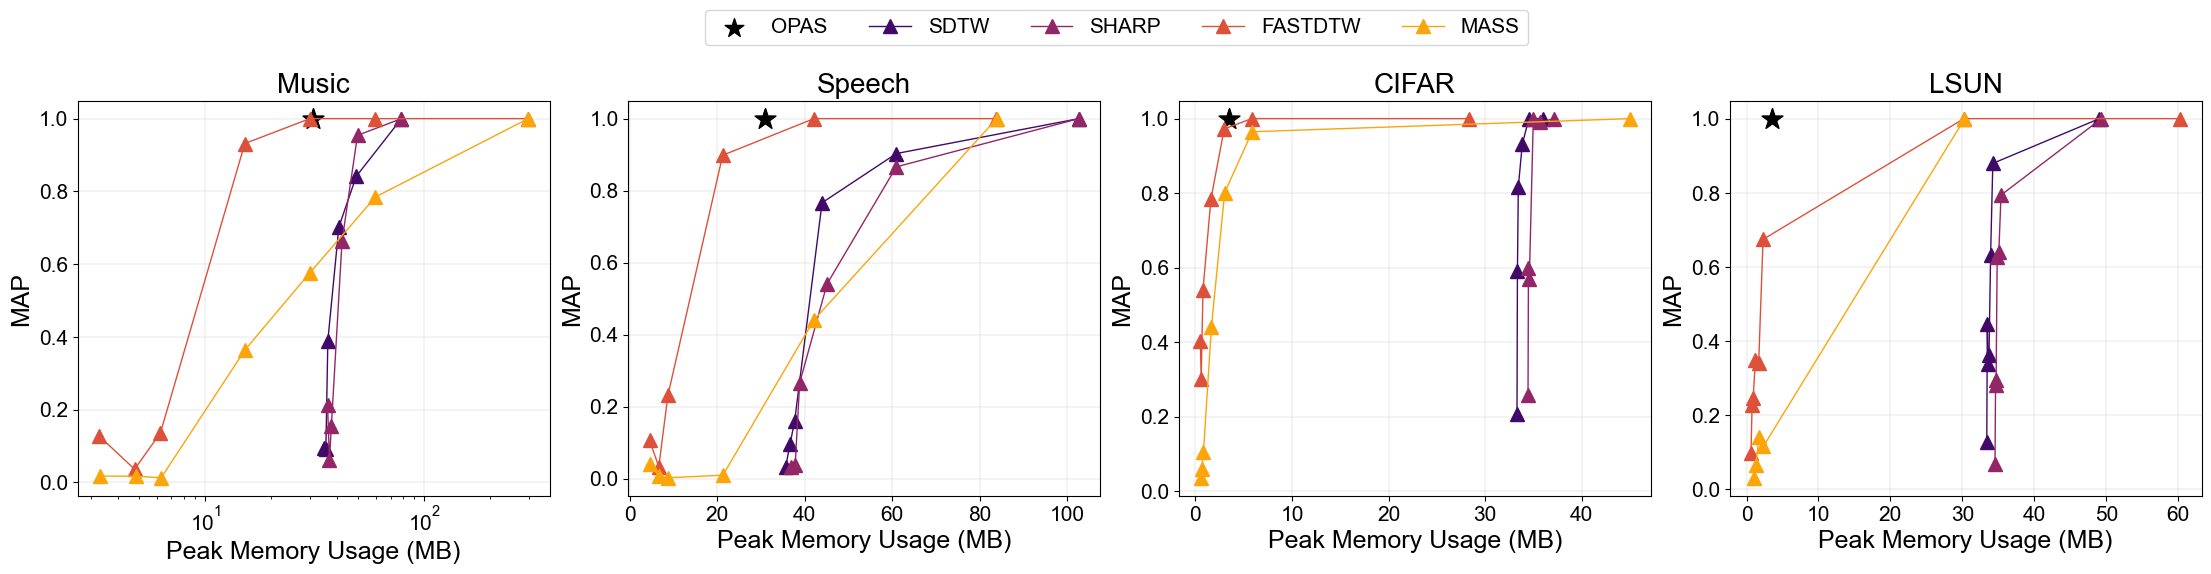

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import matplotlib as mpl

mpl.rcParams['font.family'] = "Arial"

opas_mem = {
    'audio': 30.9752,
    'speech': 30.9839,
    'cifar': 3.4956,
    'lsun': 3.5683
}
METHOD_NAME = "OPAS"

fig, ax = plt.subplots(1,4, figsize=(22,5), constrained_layout=True)
# fig.subplots_adjust(hspace=0.3)
methods = ["sdtw", "sharp", "fastdtw", "mass"]

plot_markersize = 10
opas_markersize = 250
opas_idmarkersize = 200
axis_fontsize = 18
title_fontsize = 20
label_fontsize = 15

for n, dataset in enumerate(["audio", "speech", "cifar", "lsun"]):
    colors = plt.cm.inferno(np.linspace(0.2, 0.8, 4))

    ax[n].scatter(opas_mem[dataset], 1, c='black', marker='*', s=opas_markersize)
    ax[n].scatter(opas_mem[dataset], 1, c='black', marker='*', s=opas_idmarkersize, label=METHOD_NAME)
    ax[n].tick_params(axis='both', which='major', labelsize=label_fontsize)

    for n_, method in enumerate(methods):
        logfile = f"data/memory_{method}.log"
        with open(logfile, "r") as f:
            lines = f.readlines()
        lines = [line.strip("\n") for line in lines]

        dataset_data = dict()
        for line in lines:
            if line.startswith("Dataset"):
                dataset_ = line.split(":")[1].strip()
                dataset_data[dataset_] = []
            else:
                dataset_data[dataset_].append([float(i) for i in line.split("\t")])

        N = len(dataset_data.keys())
        dataset_data[dataset] = np.array(dataset_data[dataset])

        sl = slice(1, None)
        if method == "fastdtw":
            if dataset != "speech":
                sl = slice(None)
        if method == "mass":
            if dataset == "audio": 
                ax[n].set_xscale('log')
            if dataset != "speech":
                sl = slice(None)
            if dataset == "lsun":
                sl = slice(1, -2, None)

        memory = dataset_data[dataset][:,0][sl]
        MAP = dataset_data[dataset][:,1][sl]
        label = method.upper()
        ax[n].plot(memory, MAP, linestyle='-', c=colors[n_], linewidth=1, marker='^', markersize=plot_markersize, label=label)
    
    ax[n].set_axisbelow(True)
    ax[n].grid(linewidth=0.2)
    if dataset == "audio":
        dataset = "music"
    title = dataset.upper() if dataset in ["cifar", "lsun"] else dataset.capitalize()


    ax[n].set_title(title, fontsize=title_fontsize)
    ax[n].set_xlabel("Peak Memory Usage (MB)", fontsize=axis_fontsize)
    ax[n].set_ylabel("MAP", fontsize=axis_fontsize)
    handles, labels = ax[n].get_legend_handles_labels()

legend = fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=15)
coords = legend.get_window_extent().get_points()[0]
fig.legends = []
scale = fig.get_window_extent().get_points()[1]
fig.legend(handles, labels, bbox_to_anchor=(coords[0]/(scale[0]), coords[1]/(scale[1])+0.23), loc=2, ncol=5, fontsize=15)
fig.savefig('map_vs_memory.pdf', bbox_inches='tight')
plt.show()